In [ ]:
!pip install -q transformers sentencepiece torch sentence-transformers tqdm matplotlib nltk

In [ ]:
# CELL 2: Imports & GPU check
import os, re, json, requests, time
from typing import List, Dict, Tuple, Optional
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sentence_transformers import SentenceTransformer, util

import nltk
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import wordnet as wn
lemmatizer = WordNetLemmatizer()

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    !nvidia-smi

PyTorch: 2.8.0+cu126
CUDA available: True
Thu Nov 13 16:12:27 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----

In [ ]:
# CELL 3: T4-optimized configuration (tweakable)
BASE_URL = "https://raw.githubusercontent.com/nlee0212/BLEnD/main/data/annotations/"
CACHE_DIR = "blend_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# Models
DEFAULT_MODEL_GPU = "google/flan-t5-large"   # T4-friendly large model
DEFAULT_MODEL_CPU = "google/flan-t5-base"    # CPU fallback

# Embedding for semantic matching
EMBED_MODEL = "all-MiniLM-L6-v2"

# Decoding / scoring params tuned for T4
NUM_BEAMS = 12
NUM_RETURN_SEQS = 8
MAX_NEW_TOKENS = 20
SIM_THRESHOLD = 0.70   # stricter similarity threshold for precision

# Misc
USE_LOCAL_FEWSHOT = True
SAMPLES = 100   # you can change this depending on how many examples you want to run

# Hyperparameter sweep toggle
RUN_SWEEP = False
SWEEP_CONFIG = {
    "sim_thresholds": [0.64, 0.68, 0.70, 0.72],
    "num_beams": [8, 12],
    "num_return_seqs": [4, 8],
    "val_size": 30
}

# Extended country mapping (can be extended or you can pass a direct URL)
COUNTRY_MAPPING = {
    'US': 'US_data.json', 'UK': 'UK_data.json', 'China': 'China_data.json',
    'South Korea': 'South_Korea_data.json', 'Spain': 'Spain_data.json',
    'Mexico': 'Mexico_data.json', 'Indonesia': 'Indonesia_data.json',
    'Greece': 'Greece_data.json', 'Iran': 'Iran_data.json',
    'Algeria': 'Algeria_data.json', 'Azerbaijan': 'Azerbaijan_data.json',
    'Assam': 'Assam_data.json', 'West Java': 'West_Java_data.json',
    'Northern Nigeria': 'Northern_Nigeria_data.json', 'Ethiopia': 'Ethiopia_data.json',
    'North Korea': 'North_Korea_data.json', 'Brazil': 'Brazil_data.json',
    'India': 'India_data.json', 'Nigeria': 'Nigeria_data.json', 'Turkey': 'Turkey_data.json',
    'Japan': 'Japan_data.json', 'South Africa': 'South_Africa_data.json'
}


In [ ]:
# CELL 4: Utilities

def normalize_text(s: str) -> str:
    if not s:
        return ""
    s = s.lower().strip()
    s = re.sub(r"[^\w\s\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [lemmatizer.lemmatize(t) for t in s.split()]
    return " ".join(tokens)


def safe_request_json(url: str, timeout: int = 30) -> Optional[dict]:
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return r.json()
    except Exception as e:
        print(f"Request failed: {e} (url: {url})")
        return None


# WordNet synonym augmentation
def augment_with_synonyms(answers: List[str], max_synonyms_per_answer: int = 3) -> List[str]:
    aug = set()
    for a in answers:
        a_norm = normalize_text(a)
        if not a_norm:
            continue
        aug.add(a_norm)
        tokens = a_norm.split()
        if len(tokens) <= 2:
            head = tokens[-1]
            syns = wn.synsets(head)
            count = 0
            for s in syns:
                for lemma in s.lemmas():
                    w = normalize_text(lemma.name().replace("_", " "))
                    if w and w != a_norm:
                        aug.add(w)
                        count += 1
                        if count >= max_synonyms_per_answer:
                            break
                if count >= max_synonyms_per_answer:
                    break
    return list(aug)


In [ ]:
# CELL 5: Data loader with caching
class BLEnDDataLoader:
    def __init__(self, base_url: str = BASE_URL, country_mapping: dict = COUNTRY_MAPPING, cache_dir: str = CACHE_DIR):
        self.base_url = base_url
        self.country_mapping = country_mapping
        self.cache_dir = cache_dir

    def load_country_data(self, country: str = None, url: str = None) -> List[Dict]:
        if url:
            fetch_url = url
            fname = os.path.join(self.cache_dir, os.path.basename(url))
        elif country and country in self.country_mapping:
            fname = os.path.join(self.cache_dir, self.country_mapping[country])
            fetch_url = self.base_url + self.country_mapping[country]
        else:
            print(f"Country not found in mapping. Available keys: {list(self.country_mapping.keys())}")
            return []

        if os.path.exists(fname):
            try:
                with open(fname, "r", encoding="utf-8") as f:
                    data = json.load(f)
                print(f"Loaded cached: {fname} ({len(data)} items)")
                return [dict(content, ID=qid) for qid, content in data.items()]
            except Exception:
                os.remove(fname)

        print(f"Downloading: {fetch_url}")
        data = safe_request_json(fetch_url)
        if not data:
            return []
        with open(fname, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f"Saved cache: {fname} ({len(data)} items)")
        return [dict(content, ID=qid) for qid, content in data.items()]

    def process_data(self, raw_data: List[Dict]) -> List[Dict]:
        processed = []
        for item in raw_data:
            annotations = item.get("annotations", [])
            if annotations and len(annotations) > 0:
                all_answers_en = []
                for ann in annotations:
                    if ann.get("en_answers"):
                        all_answers_en.extend(ann["en_answers"])
                top_ann = annotations[0]
                processed.append({
                    "id": item["ID"],
                    "question_en": item.get("en_question", ""),
                    "answer_en": ", ".join(top_ann.get("en_answers", [])),
                    "all_answers_en": all_answers_en,
                    "votes": top_ann.get("count", 0)
                })
        return processed



In [ ]:
# CELL 6: Evaluator
class BLEnDEvaluator:
    def __init__(self, model_name: str, embed_model: str = EMBED_MODEL, sim_threshold: float = SIM_THRESHOLD, device: str = None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model_name = model_name
        self.embed_model = embed_model
        self.sim_threshold = sim_threshold
        self.tokenizer = None
        self.model = None
        self.embedder = SentenceTransformer(self.embed_model, device=self.device)
        print(f"Evaluator | device: {self.device} | embed: {self.embed_model} | threshold: {self.sim_threshold}")

    def load_model(self):
        try:
            print(f"Loading model {self.model_name} to {self.device} ...")
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            dtype = torch.float16 if self.device.startswith("cuda") else torch.float32
            self.model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name, torch_dtype=dtype)
            self.model.to(self.device)
            self.model.eval()
            print("Model loaded successfully.")
        except Exception as e:
            print(f"Failed to load {self.model_name}: {e}")
            fallback = DEFAULT_MODEL_CPU
            print(f"Falling back to {fallback}")
            self.tokenizer = AutoTokenizer.from_pretrained(fallback)
            self.model = AutoModelForSeq2SeqLM.from_pretrained(fallback)
            self.model.to(self.device)
            self.model.eval()

    def build_prompt(self, question: str, examples: Optional[List[Tuple[str,str]]] = None) -> str:
        examples = examples or []
        prompt = "Answer briefly in 1-3 words.\n\n"
        for q, a in examples:
            prompt += f"Q: {q}\nA: {a}\n\n"
        prompt += f"Q: {question}\nA:"
        return prompt

    def generate_candidates(self, question: str, examples: Optional[List[Tuple[str,str]]] = None,
                            max_new_tokens: int = MAX_NEW_TOKENS,
                            num_beams: int = NUM_BEAMS,
                            num_return_sequences: int = NUM_RETURN_SEQS) -> List[str]:
        if self.model is None:
            self.load_model()
        prompt = self.build_prompt(question, examples)
        inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(self.device)
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                num_return_sequences=num_return_sequences,
                early_stopping=True,
                no_repeat_ngram_size=2
            )
        cand = [self.tokenizer.decode(o, skip_special_tokens=True).strip() for o in outputs]
        seen = set()
        normed = []
        for c in cand:
            n = normalize_text(c)
            if n and n not in seen:
                seen.add(n)
                normed.append(n)
        return normed

    def semantic_best_candidate(self, candidates: List[str], gold_answers: List[str]) -> Tuple[str, float]:
        if not candidates:
            return "", 0.0
        gold_norm = [normalize_text(a) for a in gold_answers if a]
        cand_emb = self.embedder.encode(candidates, convert_to_tensor=True, show_progress_bar=False)
        gold_emb = self.embedder.encode(gold_norm, convert_to_tensor=True, show_progress_bar=False)
        sim_matrix = util.cos_sim(cand_emb, gold_emb)
        cand_best_vals, _ = sim_matrix.max(dim=1)
        best_val, best_idx = cand_best_vals.max(dim=0)
        return candidates[int(best_idx)], float(best_val)

    def check_match(self, candidate: str, gold_answers: List[str]) -> bool:
        if not candidate:
            return False
        cand_norm = normalize_text(candidate)
        gold_norm = [normalize_text(a) for a in gold_answers if a]
        for g in gold_norm:
            if g == cand_norm or g in cand_norm or cand_norm in g:
                return True
            if set(cand_norm.split()) & set(g.split()):
                return True
        emb_c = self.embedder.encode(cand_norm, convert_to_tensor=True, show_progress_bar=False)
        emb_g = self.embedder.encode(gold_norm, convert_to_tensor=True, show_progress_bar=False)
        sim = util.cos_sim(emb_c, emb_g).max().item()
        return sim >= self.sim_threshold

    def select_local_examples(self, data: List[Dict], k: int = 4) -> List[Tuple[str,str]]:
        sorted_data = sorted([d for d in data if d['question_en'] and d['all_answers_en']], key=lambda x: -x['votes'])
        chosen = []
        for d in sorted_data[:k]:
            q = d['question_en']
            a = d['all_answers_en'][0] if d['all_answers_en'] else d['answer_en']
            chosen.append((q, normalize_text(a)))
        return chosen

    def evaluate(self, data: List[Dict], num_samples: int = 50, use_local_fewshot: bool = USE_LOCAL_FEWSHOT,
                 augment_synonyms: bool = True) -> Tuple[List[Dict], Dict]:
        results = []
        sample = data[:num_samples]
        local_fs = self.select_local_examples(data, k=4) if use_local_fewshot else []
        print(f"Evaluating {len(sample)} questions; few-shot examples = {len(local_fs)}; augment_synonyms={augment_synonyms}")
        for item in tqdm(sample):
            if not item['question_en']:
                continue
            golds = item['all_answers_en'][:]
            if augment_synonyms:
                aug = augment_with_synonyms(golds)
                seen = set()
                combined = []
                for a in golds + aug:
                    n = normalize_text(a)
                    if n and n not in seen:
                        seen.add(n)
                        combined.append(n)
                golds = combined
            candidates = self.generate_candidates(item['question_en'], examples=local_fs)
            best_cand, best_sim = self.semantic_best_candidate(candidates, golds) if candidates else ("", 0.0)
            match = self.check_match(best_cand, golds)
            results.append({
                "id": item['id'],
                "question": item['question_en'],
                "true_answer": item['answer_en'],
                "all_answers": item['all_answers_en'],
                "gold_augmented": golds,
                "predicted": best_cand,
                "pred_sim": best_sim,
                "votes": item['votes'],
                "candidates": candidates,
                "match": match
            })
        total = len(results)
        correct = sum(r['match'] for r in results)
        accuracy = (correct / total * 100) if total else 0.0
        high_conf = [r for r in results if r['votes'] >= 3]
        high_conf_acc = (sum(r['match'] for r in high_conf) / len(high_conf) * 100) if high_conf else 0.0
        metrics = {
            "total": total,
            "correct": correct,
            "accuracy": accuracy,
            "high_conf_count": len(high_conf),
            "high_conf_accuracy": high_conf_acc
        }
        return results, metrics

In [ ]:
# CELL 7: Quick hyperparameter sweep
def quick_sweep(data: List[Dict], model_name: str, embed_model: str, sweep_config: dict):
    val_size = sweep_config.get("val_size", 30)
    val_data = data[:val_size]
    best = None
    best_cfg = None
    print(f"Running quick sweep on {val_size} validation items ...")
    for sim_t in sweep_config["sim_thresholds"]:
        for beams in sweep_config["num_beams"]:
            for ret in sweep_config["num_return_seqs"]:
                print(f"Testing sim={sim_t:.2f}, beams={beams}, ret={ret} ...", end=" ")
                evaluator = BLEnDEvaluator(model_name=model_name, embed_model=embed_model, sim_threshold=sim_t)
                global NUM_BEAMS, NUM_RETURN_SEQS
                old_beams, old_ret = NUM_BEAMS, NUM_RETURN_SEQS
                NUM_BEAMS, NUM_RETURN_SEQS = beams, ret
                results, metrics = evaluator.evaluate(val_data, num_samples=val_size, use_local_fewshot=True)
                NUM_BEAMS, NUM_RETURN_SEQS = old_beams, old_ret
                acc = metrics['accuracy']
                print(f"acc={acc:.2f}%")
                if best is None or acc > best:
                    best = acc
                    best_cfg = {"sim": sim_t, "beams": beams, "ret": ret, "acc": acc}
    print("Sweep complete. Best:", best_cfg)
    return best_cfg


In [ ]:
# CELL 8: Runner + visualization

def run_evaluation(country: str = "South Korea", samples: int = SAMPLES, model_name: Optional[str] = None,
                   url: Optional[str] = None, run_sweep: bool = RUN_SWEEP):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    default_model = DEFAULT_MODEL_GPU if device == "cuda" else DEFAULT_MODEL_CPU
    model_name = model_name or default_model

    loader = BLEnDDataLoader()
    if url:
        raw = loader.load_country_data(country=None, url=url)
    else:
        raw = loader.load_country_data(country=country)
    if not raw:
        print("No data loaded; aborting.")
        return None, None

    data = loader.process_data(raw)
    print(f"Loaded and processed {len(data)} items.")

    if run_sweep:
        print("Starting quick hyperparameter sweep (this will load the model multiple times)...")
        best_cfg = quick_sweep(data, model_name=model_name, embed_model=EMBED_MODEL, sweep_config=SWEEP_CONFIG)
        if best_cfg:
            print("Applying best config from sweep:", best_cfg)
            global NUM_BEAMS, NUM_RETURN_SEQS, SIM_THRESHOLD
            NUM_BEAMS = best_cfg["beams"]
            NUM_RETURN_SEQS = best_cfg["ret"]
            SIM_THRESHOLD = best_cfg["sim"]

    evaluator = BLEnDEvaluator(model_name=model_name, embed_model=EMBED_MODEL, sim_threshold=SIM_THRESHOLD)
    results, metrics = evaluator.evaluate(data, num_samples=min(samples, len(data)), augment_synonyms=True)

    out_csv = f"{country.replace(' ', '_')}_blend_final_results.csv"
    pd.DataFrame(results).to_csv(out_csv, index=False)
    print(f"Saved results CSV: {out_csv}")

    print("="*60)
    print(f"Accuracy: {metrics['accuracy']:.2f}% ({metrics['correct']}/{metrics['total']})")
    print(f"High-confidence accuracy (votes>=3): {metrics['high_conf_accuracy']:.2f}% over {metrics['high_conf_count']} items")
    print("="*60)

    try:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        correct = metrics['correct']
        incorrect = metrics['total'] - correct
        axes[0].pie([correct, incorrect], labels=["Correct", "Incorrect"], autopct="%1.1f%%", startangle=90)
        axes[0].set_title("Overall")

        votes = [r['votes'] for r in results]
        axes[1].hist(votes, bins=8, edgecolor="black")
        axes[1].set_title("Votes distribution")

        correct_votes = [r['votes'] for r in results if r['match']]
        incorrect_votes = [r['votes'] for r in results if not r['match']]
        axes[2].hist([correct_votes, incorrect_votes], bins=8, label=["Correct", "Incorrect"], alpha=0.7, edgecolor="black")
        axes[2].legend()
        axes[2].set_title("Performance by Votes")

        plt.tight_layout()
        imgname = f"{country.replace(' ', '_')}_blend_visualization_final.png"
        plt.savefig(imgname, dpi=150, bbox_inches="tight")
        print(f"Saved visualization: {imgname}")
        plt.show()
    except Exception as e:
        print("Visualization error:", e)

    for i, r in enumerate(results[:10], 1):
        ok = "✅" if r["match"] else "❌"
        print(f"{i}. {ok} Q: {r['question'][:120]}")
        print(f"    True: {r['true_answer']}")
        print(f"    Pred: {r['predicted']} (sim={r['pred_sim']:.2f})")
        print(f"    Votes: {r['votes']}")
        print(f"    Candidates (top 4): {r['candidates'][:4]}\n")

    return results, metrics


Downloading: https://raw.githubusercontent.com/nlee0212/BLEnD/main/data/annotations/Assam_data.json
Saved cache: blend_cache/Assam_data.json (500 items)
Loaded and processed 491 items.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded successfully.
Saved results CSV: Assam_blend_final_results.csv
Accuracy: 72.00% (72/100)
High-confidence accuracy (votes>=3): 80.00% over 60 items
Saved visualization: Assam_blend_visualization_final.png


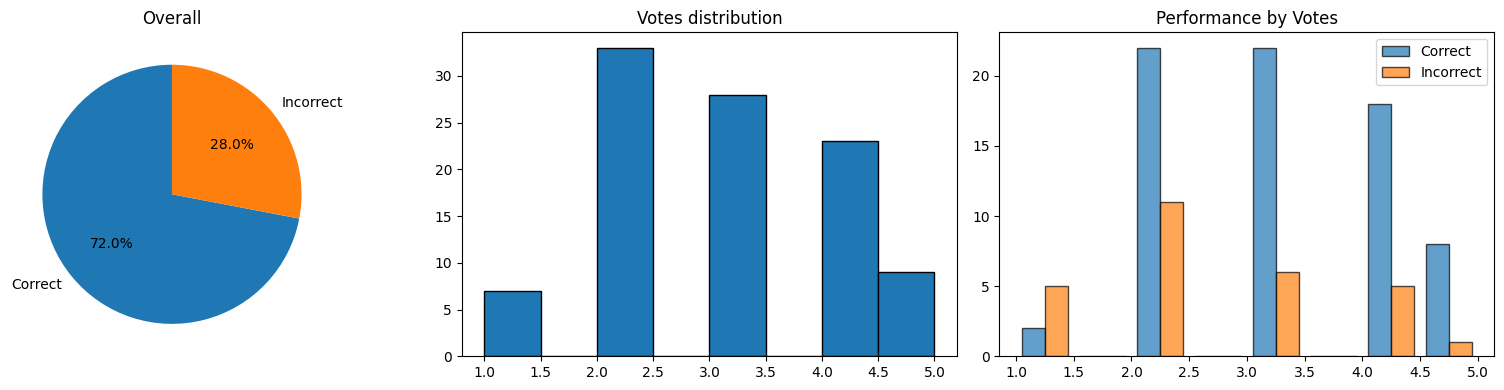

1. ❌ Q: What is a common snack for preschool kids in Assam?
    True: plantatin, musa balbisiana
    Pred: peanut (sim=0.53)
    Votes: 2
    Candidates (top 4): ['malbhog banana', 'malbhog', 'naan', 'sambar']

2. ✅ Q: What is a popular food to go with beer in Assam?
    True: chickpea
    Pred: fried rice (sim=0.64)
    Votes: 2
    Candidates (top 4): ['naan', 'kebab', 'dal', 'sambar']

3. ✅ Q: What is the most popular fruit in Assam?
    True: malbhog banana, banana
    Pred: malbhog banana (sim=1.00)
    Votes: 5
    Candidates (top 4): ['malbhog banana', 'malbhog', 'malbhog bana', 'malbog banana']

4. ✅ Q: What is a common school cafeteria food in Assam?
    True: tea
    Pred: roti (sim=0.86)
    Votes: 3
    Candidates (top 4): ['sambhar', 'naan', 'samosa', 'dal']

5. ❌ Q: What are the most commonly eaten snacks at shopping malls in Assam?
    True: panipuri, pani puri
    Pred: naan (sim=0.48)
    Votes: 4
    Candidates (top 4): ['kebab', 'ice cream', 'naan', 'chapati']

6. ✅ 

In [ ]:
# CELL 9: Run example (change country or url as needed)
if __name__ == "__main__":
    # Examples:
    # results, metrics = run_evaluation(country="South Korea", samples=100)
    # results, metrics = run_evaluation(country="Assam", samples=80)
    # results, metrics = run_evaluation(url="https://raw.githubusercontent.com/.../My_data.json", samples=50)
    results, metrics = run_evaluation(country="Assam", samples=SAMPLES, run_sweep=RUN_SWEEP)
    print("Finished.")


### Overview of the Code

This notebook is designed to evaluate the performance of a **Large Language Model (LLM)** in answering questions from a **multilingual dataset called BLEnD (Benchmarking LLMs for Explaining and Naming Decisions)**. It focuses on **question-answering (QA)** tasks, particularly by generating candidate answers and then semantically comparing them against gold-standard answers. It also includes functionalities for data loading, caching, hyperparameter tuning, and result visualization.

Here's a breakdown of its key technical components:

---

#### 1. Imports & GPU Check (Cell 2)

This cell sets up the environment by importing necessary libraries and checking for GPU availability.

*   **`torch`**: PyTorch is a fundamental library for deep learning, used here for model operations and tensor manipulations, especially with GPUs.
*   **`transformers`**: Hugging Face Transformers library is essential for loading pre-trained LLMs and their tokenizers (e.g., Flan-T5).
*   **`sentence_transformers`**: Used for generating sentence embeddings, which are crucial for semantic similarity calculations.
*   **`pandas`**: For data manipulation and saving results to CSV.
*   **`tqdm`**: For progress bars during evaluations.
*   **`matplotlib`**: For plotting and visualizing results.
*   **`nltk`**: The Natural Language Toolkit is used for text processing, specifically for lemmatization and WordNet-based synonym augmentation.
*   **`warnings`**: To suppress warnings for cleaner output.

The GPU check (`torch.cuda.is_available()` and `!nvidia-smi`) confirms if a CUDA-enabled GPU (like the T4 in Colab) is available and shows its status, indicating that the models will run on GPU if present, significantly speeding up computation.

#### 2. Configuration (Cell 3)

This cell defines various global constants and hyperparameters, making the code easily configurable.

*   **`BASE_URL`, `CACHE_DIR`**: For fetching and storing dataset files locally.
*   **`DEFAULT_MODEL_GPU`, `DEFAULT_MODEL_CPU`**: Specifies the primary LLM (Flan-T5 Large) for GPU and a smaller fallback (Flan-T5 Base) for CPU environments. These are `Seq2SeqLM` models capable of generating text.
*   **`EMBED_MODEL`**: The Sentence Transformer model (`all-MiniLM-L6-v2`) used for generating embeddings. This model is chosen for its balance of performance and efficiency.
*   **`NUM_BEAMS`, `NUM_RETURN_SEQS`, `MAX_NEW_TOKENS`**: These are decoding parameters for the LLM's text generation process.
    *   `NUM_BEAMS`: Controls the beam search width. Higher values explore more possibilities but are computationally intensive.
    *   `NUM_RETURN_SEQS`: The number of candidate sequences (answers) the LLM will generate.
    *   `MAX_NEW_TOKENS`: Limits the length of generated answers.
*   **`SIM_THRESHOLD`**: A critical hyperparameter for evaluation. It's the cosine similarity threshold used to determine if a generated answer semantically matches a gold-standard answer.
*   **`USE_LOCAL_FEWSHOT`, `SAMPLES`**: Control whether few-shot examples are used and how many samples to evaluate.
*   **`RUN_SWEEP`, `SWEEP_CONFIG`**: Parameters for an optional hyperparameter sweep to find optimal decoding and similarity settings.
*   **`COUNTRY_MAPPING`**: A dictionary mapping country names to their corresponding JSON data filenames, used by the data loader.

#### 3. Utility Functions (Cell 4)

These functions assist in text processing and data handling.

*   **`normalize_text(s: str) -> str`**:
    *   Converts text to lowercase.
    *   Removes non-alphanumeric characters (except hyphens).
    *   Replaces multiple spaces with single spaces.
    *   **Lemmatizes** each word using NLTK's `WordNetLemmatizer`. Lemmatization reduces words to their base or root form (e.g., "running" -> "run", "better" -> "good"), which is crucial for robust text comparison, especially when checking for matches regardless of tense or pluralization.

*   **`safe_request_json(url: str, timeout: int = 30) -> Optional[dict]`**:
    *   Safely makes an HTTP GET request to a URL.
    *   Attempts to parse the response as JSON.
    *   Includes error handling for network issues or invalid JSON, returning `None` on failure.

*   **`augment_with_synonyms(answers: List[str], max_synonyms_per_answer: int = 3) -> List[str]`**:
    *   Enhances the set of gold answers by adding synonyms for the last word of each answer.
    *   It uses `nltk.corpus.wordnet` to find synonyms (lemmas) for the head word of an answer. This helps improve recall during evaluation, as a generated answer might be a valid synonym of the true answer but not an exact match. For example, if the true answer is "car", and the model generates "automobile", this augmentation can help recognize it as correct.

#### 4. Data Loader (Cell 5)

**`BLEnDDataLoader`** is responsible for fetching and preparing the BLEnD dataset.

*   **`__init__`**: Initializes with the `base_url` for data, `country_mapping`, and `cache_dir`.

*   **`load_country_data(self, country: str = None, url: str = None) -> List[Dict]`**:
    *   **Caches data locally**: It first checks if the data for a given country (or URL) already exists in the `cache_dir`. If so, it loads from cache, saving repeated downloads.
    *   If not cached, it downloads the JSON data from GitHub (`base_url`) using `safe_request_json`.
    *   After downloading, it saves the data to the cache directory for future use.
    *   The `ID` field (question ID) is added to each item for easier tracking.

*   **`process_data(self, raw_data: List[Dict]) -> List[Dict]`**:
    *   Takes the raw loaded data (which can be complex, multilingual JSON).
    *   Filters for items that have English annotations (`annotations` and `en_answers`).
    *   Extracts relevant English fields: `id`, `question_en`, `answer_en` (from the top annotation), `all_answers_en` (all valid English answers), and `votes` (indicating answer consensus). This transforms the raw data into a more usable format for evaluation.

#### 5. Evaluator (Cell 6)

**`BLEnDEvaluator`** is the core component for generating answers and evaluating their correctness.

*   **`__init__`**:
    *   Initializes with the LLM `model_name`, `embed_model`, `sim_threshold`.
    *   Automatically detects the `device` (`cuda` or `cpu`).
    *   Loads the `SentenceTransformer` for embeddings immediately, as it's used frequently.
    *   The main LLM (`self.tokenizer`, `self.model`) is loaded lazily in `load_model()`.

*   **`load_model(self)`**:
    *   Loads the specified LLM (`model_name`) and its tokenizer (`AutoTokenizer`, `AutoModelForSeq2SeqLM`).
    *   Uses `torch.float16` for CUDA devices to save memory and potentially speed up inference, falling back to `float32` for CPU.
    *   Moves the model to the detected device (`cuda` or `cpu`).
    *   Sets the model to evaluation mode (`.eval()`) as it's only used for inference, disabling dropout, etc.
    *   Includes a fallback mechanism to `DEFAULT_MODEL_CPU` if the primary model fails to load.

*   **`build_prompt(self, question: str, examples: Optional[List[Tuple[str,str]]] = None) -> str`**:
    *   Constructs the input prompt for the LLM.
    *   It starts with a general instruction: "Answer briefly in 1-3 words."
    *   If `examples` (few-shot examples) are provided, they are formatted as `Q: ...\nA: ...` pairs to guide the model.
    *   Finally, the actual `question` to be answered is appended, followed by `A:` to prompt the model for its answer.

*   **`generate_candidates(self, question: str, ...)`**:
    *   This is where the LLM actually generates answers.
    *   Calls `self.load_model()` if the model hasn't been loaded yet.
    *   Tokenizes the prompt using the model's `tokenizer`.
    *   Uses `model.generate()` with beam search decoding:
        *   `max_new_tokens`, `num_beams`, `num_return_sequences` are configured to generate multiple diverse candidate answers.
        *   `early_stopping=True` stops generation once a complete sequence is found.
        *   `no_repeat_ngram_size=2` prevents repetitive phrases.
    *   Decodes the generated token IDs back into human-readable text.
    *   `normalize_text` is applied to each candidate, and duplicates are removed to ensure a unique set of normalized candidates.

*   **`semantic_best_candidate(self, candidates: List[str], gold_answers: List[str]) -> Tuple[str, float]`**:
    *   Identifies the best generated candidate answer based on **semantic similarity** to the gold answers.
    *   Normalizes both candidates and gold answers.
    *   Uses `self.embedder.encode()` (Sentence Transformer) to get embeddings for all candidates and gold answers.
    *   Calculates `util.cos_sim` (cosine similarity) between candidate embeddings and gold embeddings, resulting in a similarity matrix.
    *   For each candidate, it finds its maximum similarity to *any* gold answer.
    *   The candidate with the overall highest maximum similarity to any gold answer is chosen as the `best_cand`, and its similarity score is returned.

*   **`check_match(self, candidate: str, gold_answers: List[str]) -> bool`**:
    *   Determines if a `candidate` answer is considered a match for the `gold_answers`.
    *   Performs several checks:
        *   **Exact match (normalized)**: `cand_norm == g`.
        *   **Substring match**: `g in cand_norm` or `cand_norm in g`.
        *   **Token overlap**: Checks if any words in the normalized candidate appear in any normalized gold answer.
        *   **Semantic similarity**: If none of the above trigger, it falls back to calculating cosine similarity between the candidate and all gold answers using the `embedder`. If the highest similarity meets or exceeds `self.sim_threshold`, it's considered a match. This is crucial for handling semantically equivalent but lexically different answers.

*   **`select_local_examples(self, data: List[Dict], k: int = 4) -> List[Tuple[str,str]]`**:
    *   Selects `k` few-shot examples from the dataset to be included in the prompt.
    *   It sorts the data by `votes` (questions with higher consensus/votes are often clearer examples) in descending order and takes the top `k`.
    *   These examples (`(question_en, normalized_answer)`) are used by `build_prompt`.

*   **`evaluate(self, data: List[Dict], ...)`**:
    *   The main evaluation loop.
    *   Iterates through a `num_samples` subset of the provided `data`.
    *   Prepares gold answers, optionally augmenting them with synonyms using `augment_with_synonyms`.
    *   Generates candidate answers for each question using `generate_candidates`.
    *   Finds the `best_cand` and its `pred_sim` using `semantic_best_candidate`.
    *   Determines if it's a `match` using `check_match`.
    *   Stores detailed results for each question (question, true answer, predicted, similarity, match status, all candidates, etc.).
    *   Calculates and returns overall `accuracy` and `high_conf_accuracy` (for questions with 3 or more votes), providing key performance metrics.

#### 6. Quick Hyperparameter Sweep (Cell 7)

**`quick_sweep(data: List[Dict], model_name: str, embed_model: str, sweep_config: dict)`**:

*   This function allows for a basic hyperparameter search on a small validation subset of the data.
*   It iterates through predefined ranges of `sim_thresholds`, `num_beams`, and `num_return_seqs` (defined in `SWEEP_CONFIG`).
*   For each combination, it temporarily updates the global constants (`NUM_BEAMS`, `NUM_RETURN_SEQS`, `SIM_THRESHOLD`), instantiates `BLEnDEvaluator`, and runs a mini-evaluation on `val_data`.
*   The configuration that yields the highest accuracy on the validation set is identified as the `best_cfg`.
*   This is useful for quickly finding a reasonably good set of parameters without running a full evaluation for every combination.

#### 7. Runner and Visualization (Cell 8)

**`run_evaluation(...)`** orchestrates the entire evaluation process.

*   **Initialization**: Sets up the device (GPU/CPU) and determines the appropriate `model_name`.
*   **Data Loading**: Uses `BLEnDDataLoader` to load and process data for a specified `country` or `url`.
*   **Hyperparameter Sweep**: If `run_sweep` is True, it calls `quick_sweep` to find optimal parameters and applies them globally.
*   **Evaluation**: Instantiates `BLEnDEvaluator` with the (potentially optimized) parameters and calls its `evaluate` method.
*   **Result Storage**: Saves the detailed `results` to a CSV file using pandas.
*   **Metric Display**: Prints the overall accuracy and high-confidence accuracy.
*   **Visualization**:
    *   Generates three plots using `matplotlib.pyplot`:
        1.  A pie chart showing overall correct vs. incorrect predictions.
        2.  A histogram of vote distribution for questions.
        3.  A stacked histogram showing performance split by votes (correct vs. incorrect for different vote counts).
    *   Saves the generated visualization as a PNG image.
    *   `plt.show()` displays the plots in the Colab output.
*   **Sample Output**: Prints the first 10 evaluation results to provide a quick qualitative overview of the model's performance on individual questions.

#### 8. Example Run (Cell 9)

This cell serves as the entry point for running the evaluation. It demonstrates how to call `run_evaluation` with different parameters:

*   `country=